In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Model

In [3]:
data = load_iris()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(data.data,data.target,train_size=.7,stratify=data.target)

In [5]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                        max_features=3, min_samples_split=9,
                                        splitter='random'
                            )
clf.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features=3,
                       min_samples_split=9, splitter='random')

In [6]:
y_pred = clf.predict(X_test)
accuracy_score(y_pred=y_pred,y_true=y_test)

0.9555555555555556

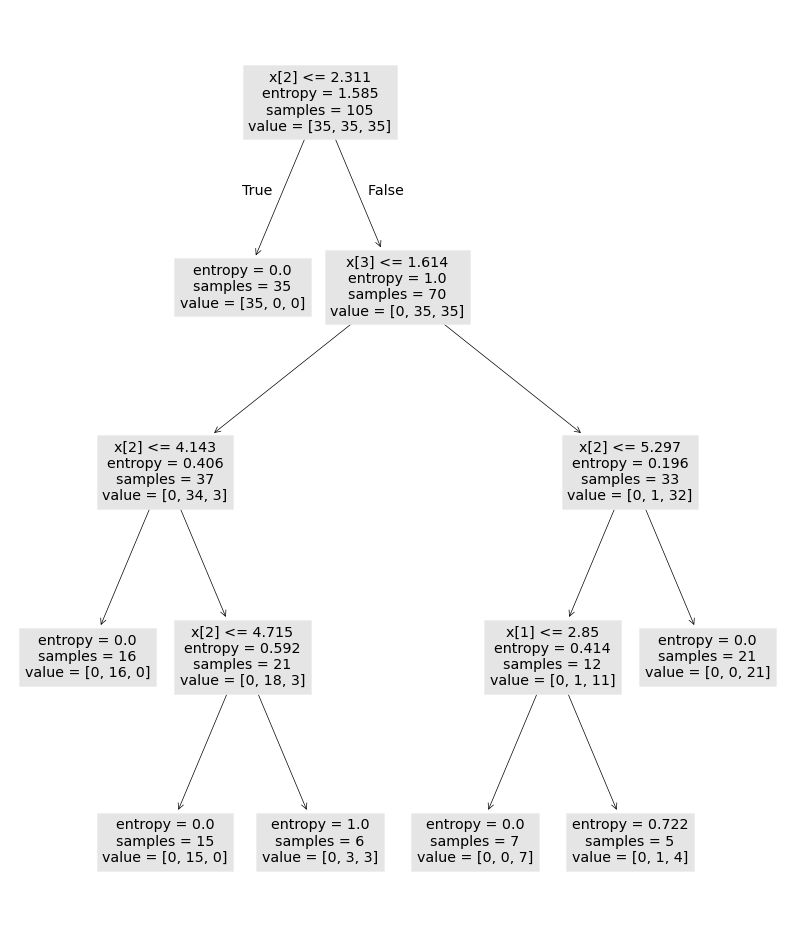

In [7]:
plt.figure(figsize=(10,12))
plot_tree(clf)
plt.show()

# Graphical Visualization

In [8]:
import dtreeviz

In [9]:
viz_model = dtreeviz.model(clf,
                           X_train=X_train,
                           y_train=y_train,
                           feature_names=data.feature_names,
                           target_name='Flowers',
                           class_names=data.target_names
                           )

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


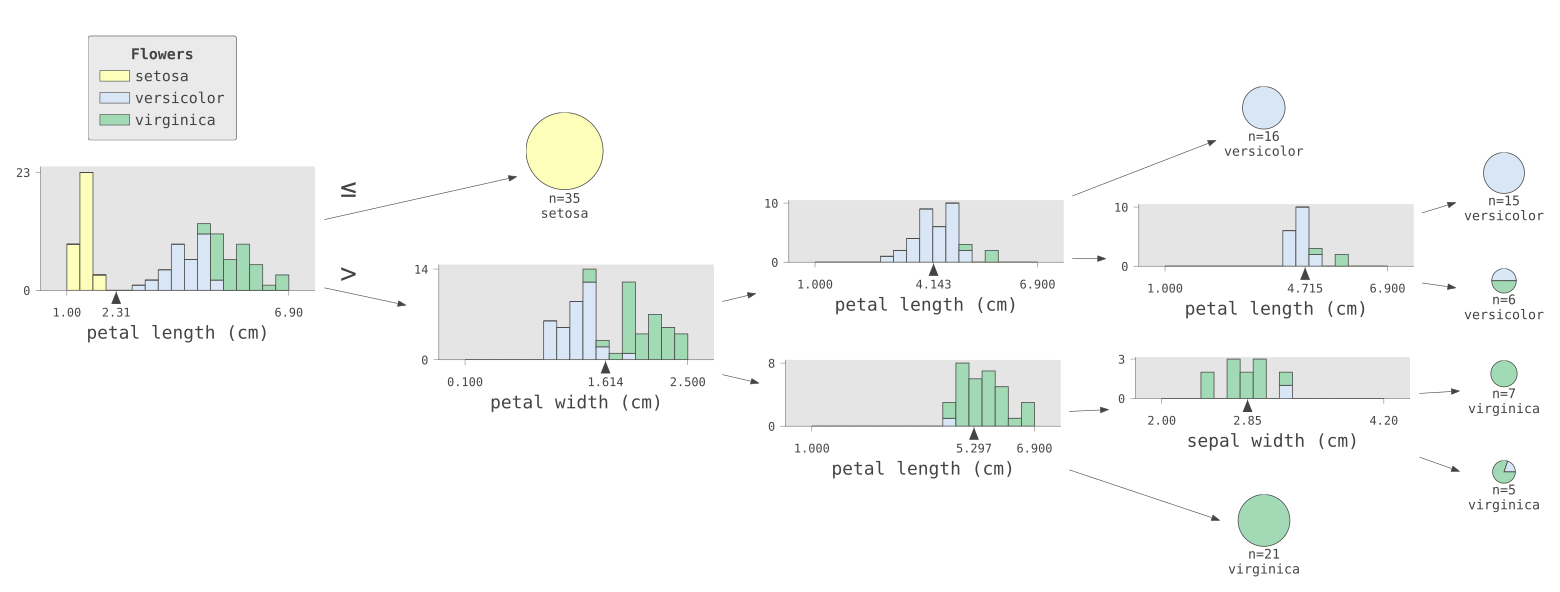

In [10]:
viz_model.view(scale=2,
               fontname='monospace',
               orientation='LR'
              )

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


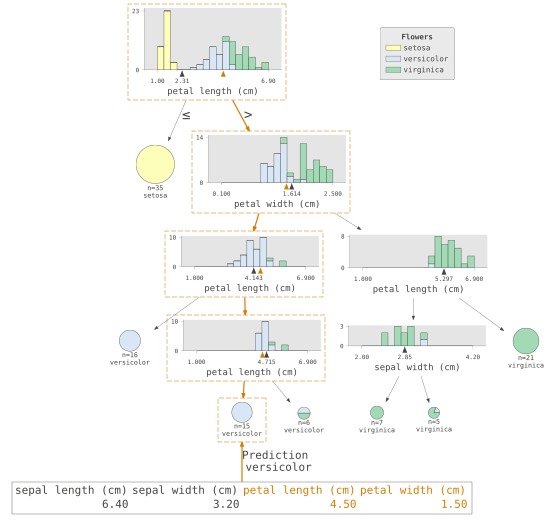

In [11]:
viz_model.view(scale=1,
               fontname='monospace',
               x=data.data[51]
              )

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


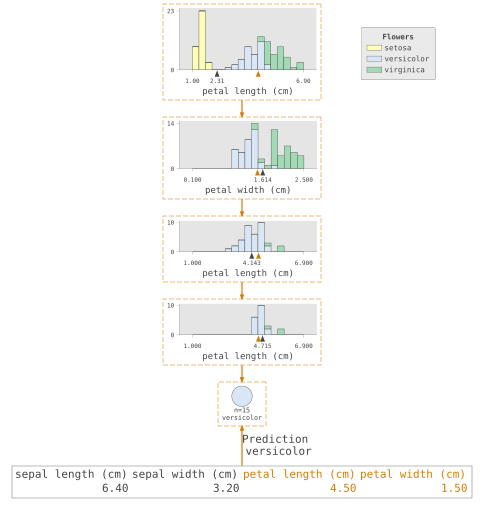

In [12]:
viz_model.view(x=data.data[51],
               show_just_path=True,
               fontname='monospace'
              )

In [13]:
print(viz_model.explain_prediction_path(data.data[51]))

4.14 <= petal length (cm)  < 4.71
petal width (cm) < 1.61



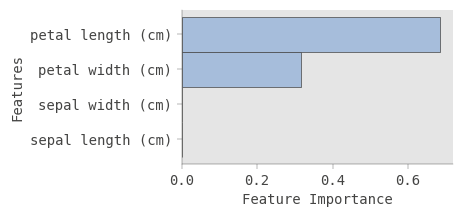

In [14]:
viz_model.instance_feature_importance(data.data[51], figsize=(3.5,2),
               fontname='monospace')

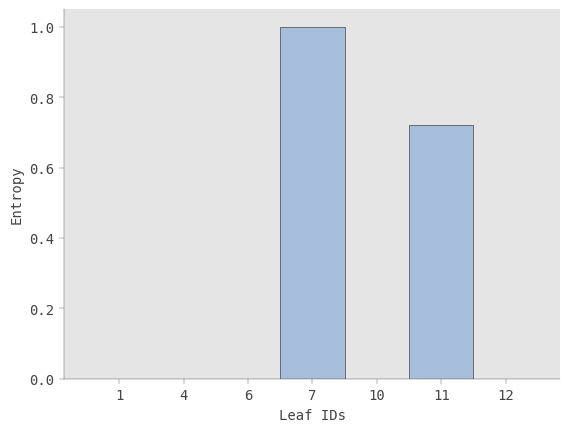

In [15]:
viz_model.leaf_purity(fontname='monospace')

In [16]:
data.feature_names, data.target_names

(['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'],
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

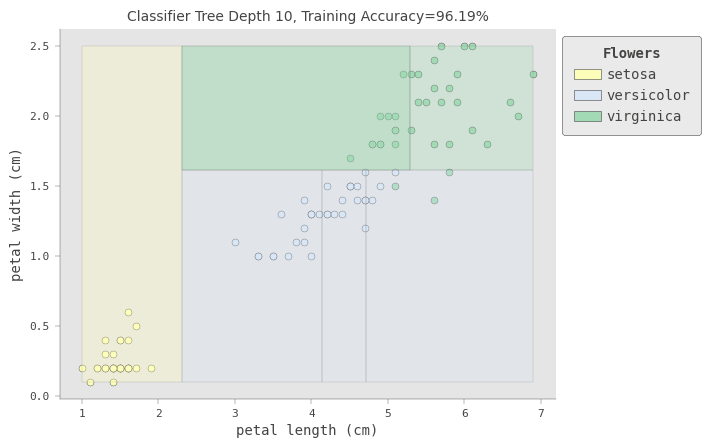

In [17]:
viz_model.ctree_feature_space(show={'legend','splits','title'},
                              features=['petal length (cm)', 'petal width (cm)'],
                              fontname='monospace',
                             )

# Hyperparameter Tuning

In [18]:
from time import time
pl = Pipeline([
    ('cls', DecisionTreeClassifier())
])

max_depth = [i for i in range(1,11)]
max_depth.append(None)
param_grid={
    'cls__criterion' : ["gini", "entropy", "log_loss"],
    'cls__splitter' : ["best", "random"],
    'cls__max_depth' : max_depth,
    # 'cls__min_samples_split': [i for i in range(2,11)],
    # 'cls__min_samples_leaf': [i for i in range(1,11)],
    # 'cls__max_features': [i for i in range(1,X.shape[1])],
}
gscv = GridSearchCV(pl, param_grid=param_grid,cv=10)
now = time()
gscv.fit(data.data,data.target)
time() - now

1.0169827938079834

In [19]:
gscv.best_params_

{'cls__criterion': 'gini', 'cls__max_depth': 8, 'cls__splitter': 'random'}

In [20]:
gscv.best_score_

np.float64(0.9733333333333334)

# Feature Importance

In [21]:
for importance, name in sorted(zip(clf.feature_importances_,data.feature_names), reverse=True):
    print(name, importance)

petal length (cm) 0.6819746629517164
petal width (cm) 0.30937697641846396
sepal width (cm) 0.008648360629819737
sepal length (cm) 0.0
